# Movement Regularity — the maths

**What it answers:** how steady / repeating someone's motion is in a short window.

**How it's done** — everything comes from the *size* of acceleration, so the
angle the device is worn at does not matter:

- **|accel|** = sqrt(x² + y² + z²) — the size of the motion (drops direction)
- **movement** = standard deviation of |accel| — how much they are moving
- **regularity** = the highest autocorrelation peak of |accel| — how strongly the motion repeats

**The deterministic rule** (two cutoffs):

- movement below a cutoff → **calm**
- else regularity above a cutoff → **rhythmic**
- else → **erratic**

**Live-safe** — it runs on a raw stream, so it handles real-world junk inside
the maths instead of pre-cleaning the data:

- a missing sample (gap) **or** an impossible reading (beyond ±16 g) is treated the
  same way — hold the last good value, so one bad sample can't fake motion
- it never looks ahead (uses only past samples, like a live device)
- if a window is too broken (over half its samples bad) → returns **uncertain** instead of guessing

In [28]:
import numpy as np

MOVE_T   = 1.0          # below this = barely moving
RHYTM_T  = 0.40         # above this = a clear repeat
ACC_MAX  = 16 * 9.81    # sensor range (±16 g); readings beyond this are impossible
MAX_MISS = 0.5          # if over half a window is bad -> "uncertain"

def fill_gaps(mag):                 # hold last good value (live: never looks ahead)
    mag = mag.copy()
    for i in range(1, len(mag)):
        if np.isnan(mag[i]):
            mag[i] = mag[i-1]
    return mag

def clean_mag(window_xyz):                         # |accel| with bad samples held over
    mag = np.sqrt((window_xyz**2).sum(axis=1))
    mag[mag > ACC_MAX] = np.nan                    # impossible spike -> treat as missing
    return fill_gaps(mag)

def features(window_xyz):                           # window_xyz shape (samples, 3)
    mag = clean_mag(window_xyz)
    movement = mag.std()                            # how much motion
    m  = mag - mag.mean()
    ac = np.correlate(m, m, mode="full")[len(m)-1:]     # autocorrelation
    regularity = 0.0 if ac[0] == 0 else (ac/ac[0])[15:128].max()
    return movement, float(regularity)

def movement_regularity(window_xyz):                # the live-safe deterministic rule
    mag = np.sqrt((window_xyz**2).sum(axis=1))
    bad = np.isnan(mag) | (mag > ACC_MAX)
    if bad.mean() > MAX_MISS or bad[0]:             # too broken / no good start value
        return "uncertain"
    movement, regularity = features(window_xyz)
    if movement < MOVE_T:    return "calm"
    if regularity > RHYTM_T: return "rhythmic"
    return "erratic"

In [29]:
import pandas as pd, glob

PROTO = "/home/voare/Documents/Synheart/Kinematics/Dataset/PAMAP2_data/PAMAP2_Dataset/Protocol/*.dat"

# PAMAP2: space-separated, no header. Load one subject to see what's inside.
f = sorted(glob.glob(PROTO))[0]
d = pd.read_csv(f, sep=r"\s+", header=None)
print("file :", f.split("/")[-1])
print("shape:", d.shape, " (rows = samples @ 100 Hz, columns = sensor channels)")

# the columns we care about:
#   col 1     = activity label (what the person was really doing)
#   col 4,5,6 = hand accelerometer x, y, z  -> this is what our rule uses
d.head()

file : subject101.dat
shape: (376417, 54)  (rows = samples @ 100 Hz, columns = sensor channels)


,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,...,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,...,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,...,0.003175,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,...,0.012698,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0


## Process the raw signal like a live stream

No pre-cleaning. We slide a 5 s window across the raw signal — one verdict per
window, like a watch — and let the rule handle gaps and spikes inside. We keep the
true activity next to each verdict (to check it later), and cut windows only
*inside* one activity so a window never mixes two. Transient (label 0) is skipped
because it has no real activity to check against.

In [ ]:
import re

WIN = 500        # 5 s window (100 Hz) — mentor's pick, and the most accurate in the sweep below
HOP = 500        # non-overlapping: one verdict every 5 s (slide less for more often)

NAMES = {1:"lying",2:"sitting",3:"standing",4:"walking",5:"running",6:"cycling",
         7:"nordic_walk",12:"ascend_stairs",13:"descend_stairs",16:"vacuum",
         17:"ironing",24:"rope_jump"}

rows = []
for path in sorted(glob.glob(PROTO)):
    sid = int(re.search(r"subject(\d+)", path).group(1))
    raw = pd.read_csv(path, sep=r"\s+", header=None)
    act = raw[1].to_numpy()
    xyz = raw[[4,5,6]].to_numpy()                 # RAW hand accel (keep NaN; rule handles it)
    change = np.where(np.diff(act) != 0)[0] + 1   # where the activity changes
    for s0, e0 in zip(np.r_[0, change], np.r_[change, len(act)]):
        a = act[s0]
        if a == 0:                                # skip transient (no real label)
            continue
        for s in range(s0, e0 - WIN + 1, HOP):    # windows inside this one activity
            w = xyz[s:s+WIN]
            verdict = movement_regularity(w)
            mv, rg = (np.nan, np.nan) if verdict == "uncertain" else features(w)
            rows.append((sid, NAMES.get(a, str(a)), mv, rg, verdict))

res = pd.DataFrame(rows, columns=["subject","activity","movement","regularity","verdict"])
print("windows:", len(res))
print(res.verdict.value_counts().to_string())
res.head()

## Validate it — three honest checks

There is no recorded "regularity" answer to grade against, so we check three things:

1. **Agreement** — does each activity get the verdict we'd obviously expect? (a sanity check)
2. **The number means "repeating"** — a walking window has a clear autocorrelation peak; a still one is flat.
3. **Orientation-proof** — rotate the window and the answer does not change (the hard guarantee).

### Check 1 — do our regions cover the real categories?

Color each window by the **real regularity of its activity** — still = calm,
steady locomotion = rhythmic, household = erratic (the genuinely fuzzy ones in
gray). Then draw our two cutoff lines on top. If the maths works, each colored
group should sit inside its matching region.

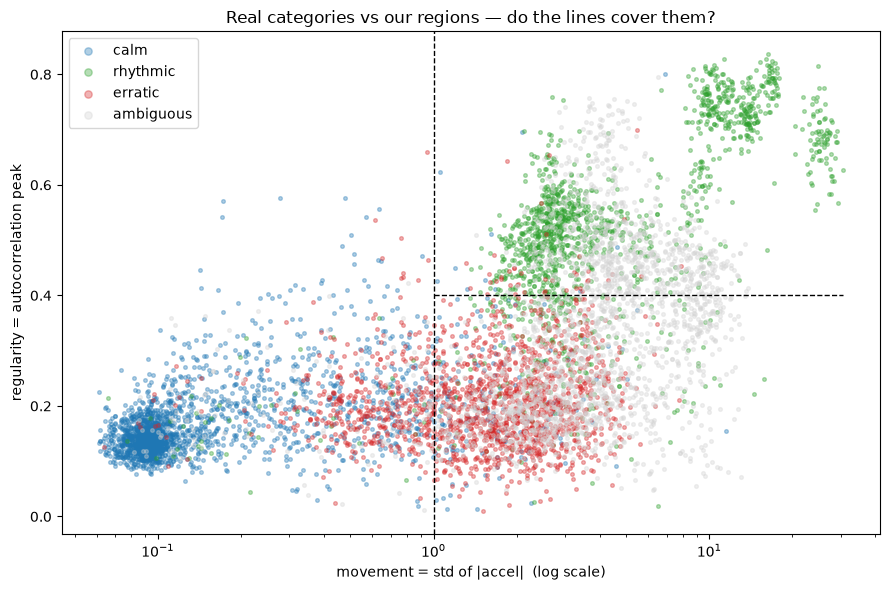

In [36]:
import matplotlib.pyplot as plt

# the true regularity of each activity (the genuinely fuzzy ones -> gray)
truth_of = {"lying":"calm","sitting":"calm","standing":"calm",
            "walking":"rhythmic","running":"rhythmic","rope_jump":"rhythmic",
            "vacuum":"erratic","ironing":"erratic"}

ok = res.dropna(subset=["movement","regularity"]).copy()   # drop 'uncertain' windows
ok["truth"] = ok.activity.map(truth_of).fillna("ambiguous")

colors = {"calm":"tab:blue", "rhythmic":"tab:green", "erratic":"tab:red", "ambiguous":"lightgray"}
plt.figure(figsize=(9,6))
for cat, c in colors.items():
    g = ok[ok.truth == cat]















    
    plt.scatter(g.movement, g.regularity, s=7, alpha=0.35, color=c, label=cat)
plt.axvline(MOVE_T, color="k", ls="--", lw=1)                       # calm | moving
plt.plot([MOVE_T, ok.movement.max()], [RHYTM_T, RHYTM_T], "k--", lw=1)  # rhythmic | erratic
plt.xscale("log")
plt.xlabel("movement = std of |accel|  (log scale)")   # x = how much motion
plt.ylabel("regularity = autocorrelation peak")        # y = how rhythmic
plt.title("Real categories vs our regions — do the lines cover them?")
plt.legend(markerscale=2)
plt.tight_layout(); plt.show()

### Check 1b — agreement with the obvious expectation

Score only the clear-cut activities; show the ambiguous ones (cycling, nordic
walking, stairs) separately rather than counting them wrong. `uncertain` windows
are left out (the rule abstained — that's not a wrong answer).

In [32]:
expected = {"lying":"calm","sitting":"calm","standing":"calm",
            "walking":"rhythmic","running":"rhythmic","rope_jump":"rhythmic",
            "vacuum":"erratic","ironing":"erratic"}
ambiguous = {"cycling","nordic_walk","ascend_stairs","descend_stairs"}

scored = res[(res.verdict != "uncertain") & (res.activity.isin(expected))].copy()
scored["expected"] = scored.activity.map(expected)
agree = (scored.verdict == scored.expected).mean()
print(f"agreement on clear activities: {agree*100:.1f}%  ({len(scored)} windows)")
print(f"ambiguous (shown, not scored): {sorted(ambiguous)}\n")

# full per-activity breakdown — nothing hidden
print("verdict share per activity:")
print(pd.crosstab(res.activity, res.verdict, normalize="index").round(2))

agreement on clear activities: 82.9%  (5281 windows)
ambiguous (shown, not scored): ['ascend_stairs', 'cycling', 'descend_stairs', 'nordic_walk']

verdict share per activity:
verdict         calm  erratic  rhythmic  uncertain
activity                                          
ascend_stairs   0.09     0.41      0.50       0.00
cycling         0.05     0.94      0.00       0.00
descend_stairs  0.10     0.51      0.38       0.00
ironing         0.39     0.59      0.02       0.00
lying           0.94     0.06      0.00       0.00
nordic_walk     0.02     0.44      0.54       0.01
rope_jump       0.05     0.23      0.71       0.02
running         0.04     0.04      0.91       0.01
sitting         0.92     0.07      0.00       0.00
standing        0.89     0.10      0.01       0.00
vacuum          0.05     0.92      0.03       0.00
walking         0.02     0.19      0.76       0.03


### Check 1c — how legit it gets over a time range

One 5 s window is a snapshot; a real device watches continuously. If we take a
majority vote over the last few windows (a time range), the flicker smooths out and
the verdict gets more accurate. The cost: a longer range reacts slower to a real
change — so this is a stability-vs-responsiveness trade-off, shown as one curve.

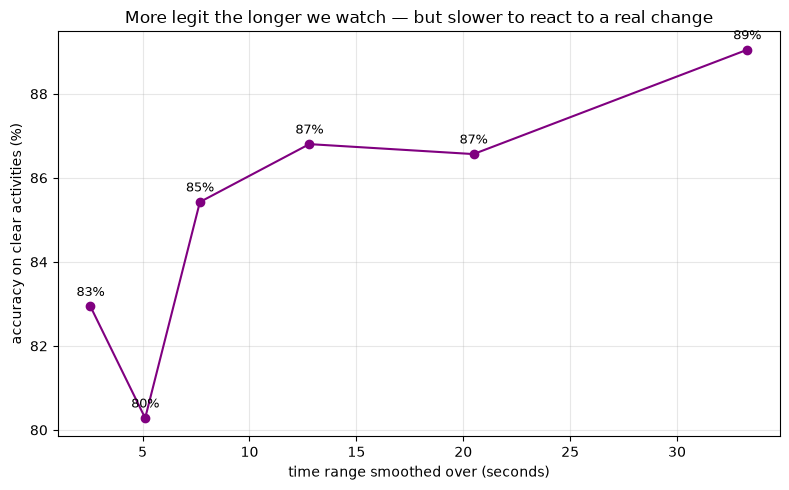

In [37]:
# how legit does it get if we smooth the verdict over a longer time range?
# (majority vote over the last k windows, within one activity run)
def smoothed_accuracy(k):
    c = t = 0
    for (sid, a), g in res.groupby(["subject", "activity"]):
        if a not in expected:
            continue
        v = list(g["verdict"]); e = expected[a]
        for i in range(len(v)):
            win = v[max(0, i-k+1):i+1]
            sm = max(set(win), key=win.count)      # most common verdict in last k
            if sm == "uncertain":
                continue
            t += 1; c += (sm == e)
    return 100 * c / t

ks    = [1, 2, 3, 5, 8, 13]
accs  = [smoothed_accuracy(k) for k in ks]
times = [k * WIN / 100 for k in ks]                # time range in seconds

plt.figure(figsize=(8,5))
plt.plot(times, accs, "o-", color="purple")
for x, y in zip(times, accs):
    plt.text(x, y + 0.25, f"{y:.0f}%", ha="center", fontsize=9)
plt.xlabel("time range smoothed over (seconds)")    # x = how long we watch
plt.ylabel("accuracy on clear activities (%)")      # y = how legit
plt.title("More legit the longer we watch — but slower to react to a real change")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Check 1d — does the window length matter?

Re-run the whole rule at 2–5 s windows (same thresholds). Accuracy is stable and
actually rises a little with length, so the choice is safe — we lock in **5 s**
(the mentor's pick, and the best here). The only cost of a longer window is coarser
timing: one verdict every 5 s instead of every 2.5 s.

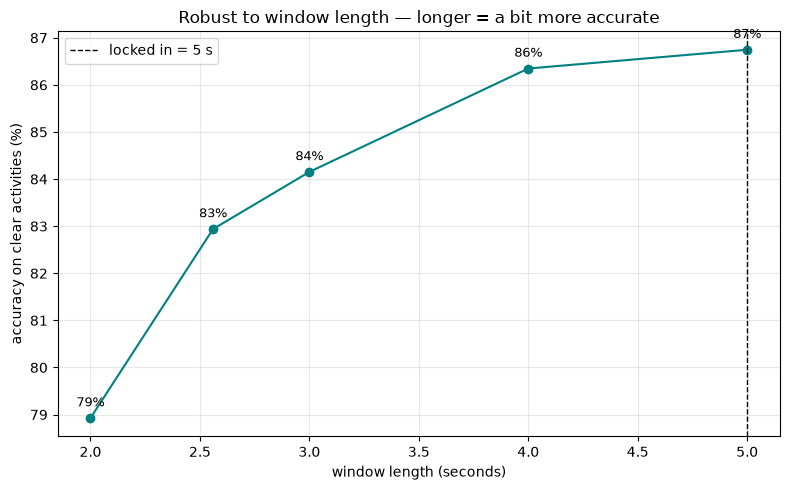

In [38]:
# does the WINDOW LENGTH matter? re-run the whole rule at 2-5 s windows (same thresholds)
raws = [pd.read_csv(p, sep=r"\s+", header=None, usecols=[1,4,5,6]) for p in sorted(glob.glob(PROTO))]

def window_accuracy(win):
    c = t = 0
    for raw in raws:
        act = raw[1].to_numpy(); xyz = raw[[4,5,6]].to_numpy()
        ch = np.where(np.diff(act) != 0)[0] + 1
        for s0, e0 in zip(np.r_[0, ch], np.r_[ch, len(act)]):
            name = NAMES.get(act[s0])
            if name not in expected:                    # only clear activities
                continue
            e = expected[name]
            for s in range(s0, e0 - win + 1, win):
                v = movement_regularity(xyz[s:s+win])
                if v == "uncertain":
                    continue
                t += 1; c += (v == e)
    return 100 * c / t

secs  = [2, 2.56, 3, 4, 5]
acc_w = [window_accuracy(int(s*100)) for s in secs]

plt.figure(figsize=(8,5))
plt.plot(secs, acc_w, "o-", color="teal")
for x, y in zip(secs, acc_w):
    plt.text(x, y + 0.25, f"{y:.0f}%", ha="center", fontsize=9)
plt.axvline(5, color="k", ls="--", lw=1, label="locked in = 5 s")
plt.xlabel("window length (seconds)")             # x = window size
plt.ylabel("accuracy on clear activities (%)")    # y = how legit
plt.title("Robust to window length — longer = a bit more accurate")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Check 2 — the number really measures repetition

Autocorrelation slides the signal against itself. If the motion repeats it lines
up at the step period (tall peak); if it's still or erratic there is nothing to
line up with (flat).

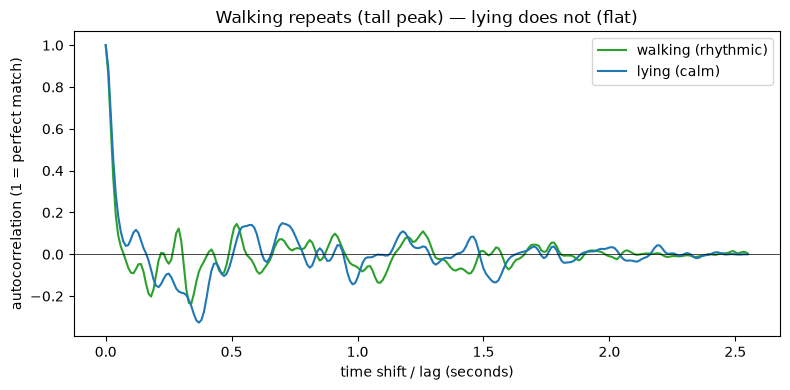

In [33]:
aid = d[1].to_numpy()
xyz_all = d[[4,5,6]].to_numpy()

def autocorr_window(act_id):
    idx = np.where(aid == act_id)[0]
    mag = clean_mag(xyz_all[idx[200:200+WIN]])   # a clean stretch of this activity
    m = mag - mag.mean()
    ac = np.correlate(m, m, mode="full")[len(m)-1:]
    return ac / ac[0]

lags = np.arange(WIN) / 100
plt.figure(figsize=(8,4))
plt.plot(lags, autocorr_window(4), color="tab:green", label="walking (rhythmic)")
plt.plot(lags, autocorr_window(1), color="tab:blue",  label="lying (calm)")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("time shift / lag (seconds)")             # x = how far we slid the signal
plt.ylabel("autocorrelation (1 = perfect match)")    # y = how well it lines up
plt.title("Walking repeats (tall peak) — lying does not (flat)")
plt.legend(); plt.tight_layout(); plt.show()

### Check 3 — orientation-proof (rotation test)

Spin every window by a random 3D rotation (device worn at a different angle) and
recompute. Both numbers come from |accel|, and rotation does not change a vector's
length — so the dial must not move.

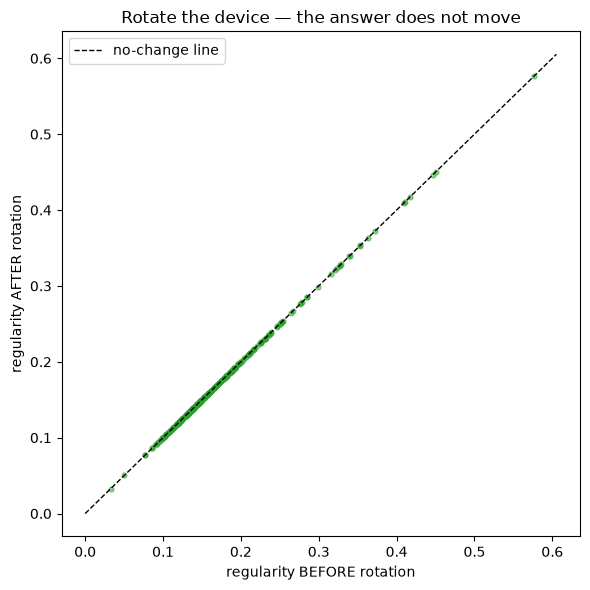

max change in movement  : 8.881784197001252e-16
max change in regularity: 4.08006961549745e-15


In [34]:
from scipy.spatial.transform import Rotation
rng = np.random.default_rng(0)

change = np.where(np.diff(aid) != 0)[0] + 1
wins = []
for s0, e0 in zip(np.r_[0, change], np.r_[change, len(aid)]):
    if aid[s0] == 0:
        continue
    for s in range(s0, e0 - WIN + 1, WIN):
        w = xyz_all[s:s+WIN]
        if not np.isnan(w).any():
            wins.append(w)
wins = wins[:300]

before = np.array([features(w) for w in wins])
after  = np.array([features(w @ Rotation.random(random_state=int(rng.integers(1e6))).as_matrix().T) for w in wins])

plt.figure(figsize=(6,6))
plt.scatter(before[:,1], after[:,1], s=12, alpha=0.5, color="tab:green")
lim = [0, max(before[:,1].max(), after[:,1].max())*1.05]
plt.plot(lim, lim, "k--", lw=1, label="no-change line")
plt.xlabel("regularity BEFORE rotation")   # x = original
plt.ylabel("regularity AFTER rotation")    # y = rotated
plt.title("Rotate the device — the answer does not move")
plt.legend(); plt.tight_layout(); plt.show()

print("max change in movement  :", np.abs(before[:,0]-after[:,0]).max())
print("max change in regularity:", np.abs(before[:,1]-after[:,1]).max())